# Workforce Burnout Prediction System


---

**Project Title:** Workforce Burnout Prediction, Sick-Day Forecasting & HR Intervention Recommendation System  
**Dataset:** IBM HR Analytics Employee Attrition & Performance Dataset  
**Team:** Faith Ngendo,Alan Muchiri,William Nyawir,Sarah Owendi,Anthony Njeru
 


###  What is this project about?

Employee burnout is a serious problem in many organizations. It happens when employees experience
long-term stress at work that is not properly managed. Burnout leads to lower productivity,
increased absenteeism, and higher employee turnover.

In this project, we are building a **machine learning system** that can:

- **Predict** which employees are at risk of burnout (Stage 1)
- Forecast how many sick days they might take (Stage 2)
- Recommend HR interventions to help (Stage 3)



---
## Section 1: Import Libraries

We start by importing all the Python libraries we will need throughout this notebook.



In [ ]:
# Standard data manipulation libraries 
import pandas as pd
import numpy as np

#  Visualization libraries 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#  Scikit-learn: preprocessing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

#  Scikit-learn: models 
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

#  XGBoost: gradient boosting 
from xgboost import XGBRegressor

#  Scikit-learn: evaluation metrics 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Settings 
# Suppress unnecessary warnings to keep output clean
import warnings
warnings.filterwarnings('ignore')

# Set a consistent random seed so results are reproducible
RANDOM_STATE = 42

# Set default plot style and figure size
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print(" All libraries imported successfully!")


 All libraries imported successfully!


---
##  Section 2: Load the Dataset

Our journey starts here. We load the **IBM HR Analytics Employee Attrition & Performance** dataset
from Kaggle, which contains information about **1,470 employees** across **35 different attributes**.

This dataset is the foundation for our entire burnout prediction system. It includes key workplace
metrics like job satisfaction, work-life balance, overtime status, salary, and more — exactly the
indicators we'll use to identify at-risk employees.

**Dataset Overview:**
- **1,470 employees** with comprehensive HR records
- **35 attributes** capturing job, personal, and performance information
- Features like `JobSatisfaction`, `WorkLifeBalance`, `EnvironmentSatisfaction` (1-4 scale)
- `MonthlyIncome` ranging from ~1K to ~20K, showing salary diversity
- Mix of categorical (Department, Gender) and numerical (Age, Salary) features

In [ ]:
# Load the dataset from CSV 
df = pd.read_csv('Data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df1 = pd.read_csv('Data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 1470 rows × 35 columns


In [ ]:
# Preview the first 5 rows 
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
# Display all column names
print("Column names in the dataset:")
print(df.columns.tolist())

Column names in the dataset:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [ ]:
# Show data types for each column
print("Data types for each column:")
print(df.dtypes)

Data types for each column:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel           

In [ ]:
# Summary statistics of numerical columns 
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Observations:**
- The dataset has **1,470 rows and 35 columns** — a reasonable size for machine learning.
- Features like `JobSatisfaction`, `WorkLifeBalance`, and `EnvironmentSatisfaction` are rated on a
  scale of **1 to 4**, where 1 = lowest and 4 = highest.
- `MonthlyIncome` ranges from about **1,009 to 19,999**, showing a wide spread of salaries.
- Some columns like `OverTime`, `Attrition`, `Gender`, and `Department` are **categorical** (text) columns.

---
## Section 3: Data Cleaning & Preprocessing

With our raw data loaded, we need to prepare it for machine learning. **Real-world data is messy** — 
it has missing values, duplicates, and irrelevant columns that confuse models.

Our cleaning process removes noise and inconsistencies, leaving only high-quality features that 
meaningfully contribute to burnout prediction. This is a critical step: **garbage in, garbage out** 
applies to machine learning.

Our cleaning checklist:
1. **Check for missing values** — Can't train models on incomplete data
2. **Remove duplicates** — Prevents training bias from repeated records
3. **Drop constant columns** — Columns with one value everywhere add no information
4. **Convert categorical text to numbers** — ML algorithms need numerical inputs

### 3.1 Check for Missing Values

Missing values can cause errors in machine learning models, so we always check for them first.

In [ ]:
# Count missing values in each column 
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else " No missing values found!")

Missing values per column:
 No missing values found!


### 3.2 Check for Duplicate Rows

In [ ]:
#  Check for duplicate rows 
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates == 0:
    print("No duplicates found!")
else:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows.")

Number of duplicate rows: 0
No duplicates found!


### 3.3 Drop Constant / Irrelevant Columns

Some columns contain the **same value for every row** and therefore provide no useful information
to a machine learning model. We identify and remove them.

In [ ]:
# Identify columns with only one unique value (constant columns) 
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Constant columns to drop: {constant_cols}")

# Drop those columns
df = df.drop(columns=constant_cols)
print(f"\nDataset shape after dropping constant columns: {df.shape}")

Constant columns to drop: ['EmployeeCount', 'Over18', 'StandardHours']

Dataset shape after dropping constant columns: (1470, 32)


> **Why?** Columns like `EmployeeCount`, `StandardHours`, and `Over18` have the same value
> for every single employee. They carry zero information and are safe to remove.

### 3.4 Identify Categorical Columns

Machine learning algorithms cannot work directly with text values. We need to identify
which columns contain text and convert them to numbers.

In [ ]:
# List all categorical (text) columns 
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns ({len(cat_cols)} total):")
for col in cat_cols:
    print(f"  {col}: {df[col].unique().tolist()}")

Categorical columns (8 total):
  Attrition: ['Yes', 'No']
  BusinessTravel: ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
  Department: ['Sales', 'Research & Development', 'Human Resources']
  EducationField: ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']
  Gender: ['Female', 'Male']
  JobRole: ['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Healthcare Representative', 'Manager', 'Sales Representative', 'Research Director', 'Human Resources']
  MaritalStatus: ['Single', 'Married', 'Divorced']
  OverTime: ['Yes', 'No']


### 3.5 Encode Categorical Columns

We will use **Label Encoding** to convert categorical columns into numbers.
For example: `Yes → 1`, `No → 0`.

In [ ]:
# Apply Label Encoding to all categorical columns 
# We store the encoders in case we need to reverse the encoding later
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"  Encoded '{col}': {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\n All categorical columns encoded successfully!")

  Encoded 'Attrition': {'No': 0, 'Yes': 1}
  Encoded 'BusinessTravel': {'Non-Travel': 0, 'Travel_Frequently': 1, 'Travel_Rarely': 2}
  Encoded 'Department': {'Human Resources': 0, 'Research & Development': 1, 'Sales': 2}
  Encoded 'EducationField': {'Human Resources': 0, 'Life Sciences': 1, 'Marketing': 2, 'Medical': 3, 'Other': 4, 'Technical Degree': 5}
  Encoded 'Gender': {'Female': 0, 'Male': 1}
  Encoded 'JobRole': {'Healthcare Representative': 0, 'Human Resources': 1, 'Laboratory Technician': 2, 'Manager': 3, 'Manufacturing Director': 4, 'Research Director': 5, 'Research Scientist': 6, 'Sales Executive': 7, 'Sales Representative': 8}
  Encoded 'MaritalStatus': {'Divorced': 0, 'Married': 1, 'Single': 2}
  Encoded 'OverTime': {'No': 0, 'Yes': 1}

 All categorical columns encoded successfully!


---
##  Section 4: Feature Engineering — Creating the BurnoutRisk Target Variable

### Why do we need to create BurnoutRisk?

The original IBM HR dataset does **not** contain a column called `BurnoutRisk`.
Since we want to build a burnout prediction model, we need to **create this target variable
ourselves** using domain knowledge about what causes employee burnout.

### Our Scoring Logic

We define a **burnout score** for each employee based on the following rules:

| Feature | Condition | Score Added |
|---|---|---|
| `OverTime` | Works overtime (Yes) | +2 |
| `WorkLifeBalance` | Very poor balance (score = 1) | +2 |
| `WorkLifeBalance` | Below average balance (score = 2) | +1 |
| `JobSatisfaction` | Very dissatisfied (score = 1) | +2 |
| `JobSatisfaction` | Dissatisfied (score = 2) | +1 |
| `EnvironmentSatisfaction` | Very poor environment (score = 1) | +2 |
| `EnvironmentSatisfaction` | Poor environment (score = 2) | +1 |
| `MonthlyIncome` | Low income (< 3,000) | +1 |
| `YearsAtCompany` | Long tenure (> 10 years) | +1 |

**Maximum possible score = 12**

Then we assign burnout risk levels:
- **High**: Score ≥ 5
- **Medium**: Score 2 – 4
- **Low**: Score 0 – 1

> **Reasoning:** Employees who work overtime AND have low satisfaction AND poor work-life
> balance are most at risk of burnout. Low income adds financial stress. Long tenure without
> satisfaction could signal career stagnation — another burnout contributor.

In [ ]:
#  IMPORTANT: Since OverTime was label-encoded above, let's check its encoded values 
# 'No' → 0, 'Yes' → 1  (LabelEncoder sorts alphabetically)
print("OverTime encoding mapping:")
print(dict(zip(
    label_encoders['OverTime'].classes_,
    label_encoders['OverTime'].transform(label_encoders['OverTime'].classes_)
)))

OverTime encoding mapping:
{'No': 0, 'Yes': 1}


In [ ]:
# Define the burnout scoring function 
def calculate_burnout_score(row):
    """
    Calculate a burnout risk score for a single employee record.
    Higher score = higher burnout risk.
    """
    score = 0

    # OverTime: 1 means 'Yes' after encoding
    if row['OverTime'] == 1:
        score += 2

    # Work-Life Balance: 1 = Bad, 2 = Good, 3 = Better, 4 = Best
    if row['WorkLifeBalance'] == 1:
        score += 2
    elif row['WorkLifeBalance'] == 2:
        score += 1

    # Job Satisfaction: 1 = Low, 2 = Medium, 3 = High, 4 = Very High
    if row['JobSatisfaction'] == 1:
        score += 2
    elif row['JobSatisfaction'] == 2:
        score += 1

    # Environment Satisfaction: 1 = Low, 2 = Medium, 3 = High, 4 = Very High
    if row['EnvironmentSatisfaction'] == 1:
        score += 2
    elif row['EnvironmentSatisfaction'] == 2:
        score += 1

    # Low income adds financial stress
    if row['MonthlyIncome'] < 3000:
        score += 1

    # Long tenure without growth can lead to burnout
    if row['YearsAtCompany'] > 10:
        score += 1

    # Map score to risk category
    if score >= 5:
        return 'High'
    elif score >= 2:
        return 'Medium'
    else:
        return 'Low'


# Apply the function to every row to create the BurnoutRisk column 
df['BurnoutRisk'] = df.apply(calculate_burnout_score, axis=1)

print(" BurnoutRisk column created!")
print("\nClass distribution:")
print(df['BurnoutRisk'].value_counts())
print("\nClass proportions:")
print(df['BurnoutRisk'].value_counts(normalize=True).round(3))

 BurnoutRisk column created!

Class distribution:
Medium    886
Low       414
High      170
Name: BurnoutRisk, dtype: int64

Class proportions:
Medium    0.603
Low       0.282
High      0.116
Name: BurnoutRisk, dtype: float64


> **Result:** Our scoring system creates a reasonably distributed dataset with three classes.
> `Medium` risk is the most common (makes sense — most employees experience some workplace stress),
> `Low` is next, and `High` is the smallest group (only the most stressed employees score high).

---
## Section 5: Exploratory Data Analysis (EDA)

EDA helps us understand the data visually before we build models.
We will create several charts to understand patterns related to burnout risk.

### 5.1 BurnoutRisk Class Distribution

Let's see how many employees fall into each burnout risk category.

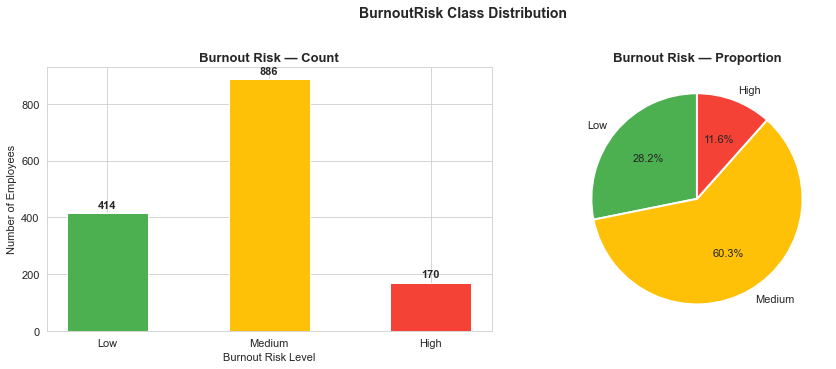

In [ ]:
# Plot BurnoutRisk class distribution 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Define a consistent colour palette for the 3 risk classes
palette = {'Low': '#4CAF50', 'Medium': '#FFC107', 'High': '#F44336'}
order   = ['Low', 'Medium', 'High']

# Count plot
counts = df['BurnoutRisk'].value_counts().reindex(order)
bars = axes[0].bar(order, counts, color=[palette[k] for k in order], edgecolor='white', width=0.5)
axes[0].set_title('Burnout Risk — Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Burnout Risk Level')
axes[0].set_ylabel('Number of Employees')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=order, autopct='%1.1f%%',
            colors=[palette[k] for k in order],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Burnout Risk — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('BurnoutRisk Class Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretation:**
- About **60% of employees** fall into the `Medium` burnout risk category.
- Around **28% are Low** risk — relatively satisfied and not overworked.
- About **12% are High** risk — these are the employees who need immediate HR attention.

The class distribution is **imbalanced**, with `High` being underrepresented.
This is realistic — in any organization, most employees are not at extreme burnout risk.
We will keep this in mind when evaluating our models.

### 5.2 Correlation Heatmap

A correlation heatmap shows how strongly each numerical feature is related to every other feature.
Values close to **+1** mean strong positive correlation; close to **-1** means strong negative correlation.

We focus on a subset of key features to keep the chart readable.

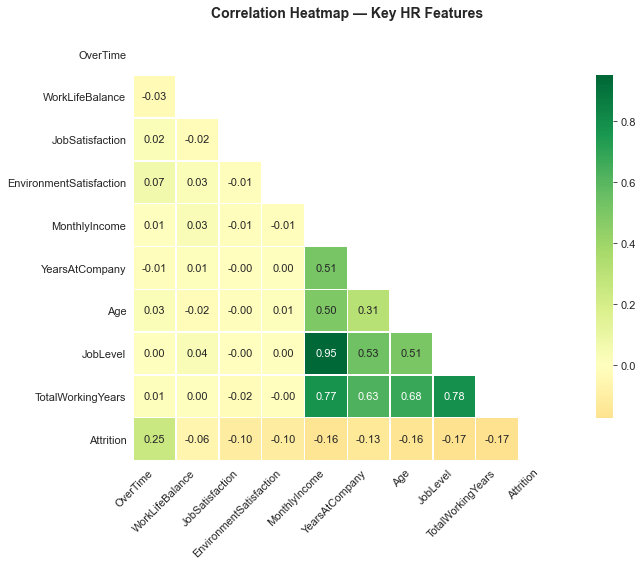

In [ ]:
# Select key features for correlation analysis 
key_features = [
    'OverTime', 'WorkLifeBalance', 'JobSatisfaction',
    'EnvironmentSatisfaction', 'MonthlyIncome', 'YearsAtCompany',
    'Age', 'JobLevel', 'TotalWorkingYears', 'Attrition'
]

corr_matrix = df[key_features].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle (redundant)
sns.heatmap(
    corr_matrix, mask=mask,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap — Key HR Features', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Interpretation:**
- `JobLevel` and `MonthlyIncome` have a **strong positive correlation** (~0.95) — higher job levels earn more.
- `TotalWorkingYears`, `Age`, and `YearsAtCompany` are **positively correlated** — older employees tend to have more experience.
- `OverTime` shows a small **positive correlation** with `Attrition`, confirming that working overtime
  increases the chance of an employee leaving — a key burnout signal.
- `JobSatisfaction` and `EnvironmentSatisfaction` have **very little correlation** with each other,
  suggesting they measure different aspects of the work experience.

### 5.3 OverTime vs BurnoutRisk

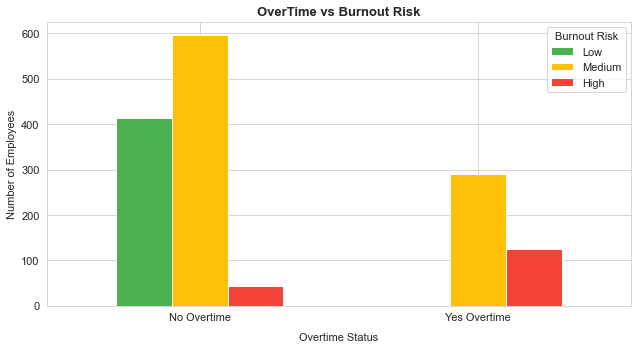

In [ ]:
#  OverTime vs BurnoutRisk 
# The encoded values: 0 = No overtime, 1 = Yes overtime
fig, ax = plt.subplots(figsize=(9, 5))

# Crosstab counts
ct = pd.crosstab(df['OverTime'], df['BurnoutRisk'])[order]
ct.index = ['No Overtime', 'Yes Overtime']
ct.plot(kind='bar', ax=ax, color=[palette[k] for k in order],
        edgecolor='white', width=0.6)

ax.set_title('OverTime vs Burnout Risk', fontsize=13, fontweight='bold')
ax.set_xlabel('Overtime Status', labelpad=10)
ax.set_ylabel('Number of Employees')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Burnout Risk', labels=order)

plt.tight_layout()
plt.show()

**Interpretation:**
As expected from our scoring logic, employees who **work overtime** have a much higher proportion
of `Medium` and `High` burnout risk. This strongly supports the common HR knowledge that overtime
is a key driver of employee burnout.

### 5.4 Job Satisfaction vs BurnoutRisk

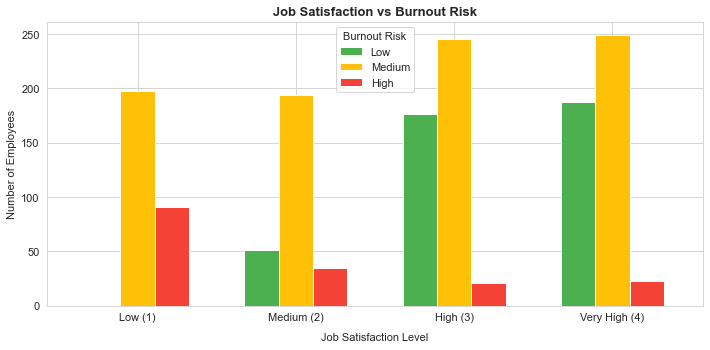

In [ ]:
# JobSatisfaction vs BurnoutRisk 
fig, ax = plt.subplots(figsize=(10, 5))

ct = pd.crosstab(df['JobSatisfaction'], df['BurnoutRisk'])[order]
ct.index = ['Low (1)', 'Medium (2)', 'High (3)', 'Very High (4)']
ct.plot(kind='bar', ax=ax, color=[palette[k] for k in order],
        edgecolor='white', width=0.65)

ax.set_title('Job Satisfaction vs Burnout Risk', fontsize=13, fontweight='bold')
ax.set_xlabel('Job Satisfaction Level', labelpad=10)
ax.set_ylabel('Number of Employees')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Burnout Risk', labels=order)

plt.tight_layout()
plt.show()

**Interpretation:**
Employees with **Low or Medium job satisfaction** tend to have higher burnout risk.
As satisfaction increases to `High (3)` and `Very High (4)`, the proportion of Low burnout risk grows.
This makes intuitive sense — employees who enjoy their jobs are less likely to burn out.

### 5.5 WorkLifeBalance vs BurnoutRisk

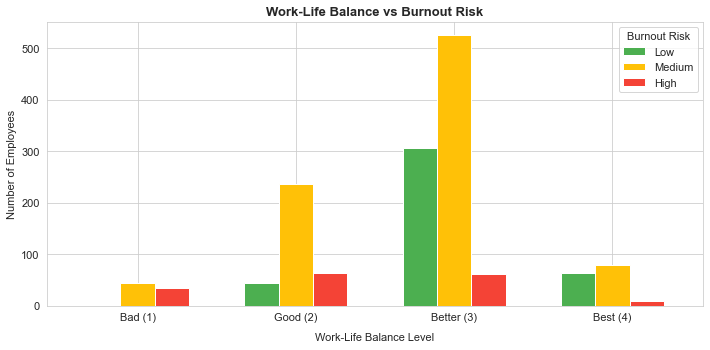

In [ ]:
# WorkLifeBalance vs BurnoutRisk 
fig, ax = plt.subplots(figsize=(10, 5))

ct = pd.crosstab(df['WorkLifeBalance'], df['BurnoutRisk'])[order]
ct.index = ['Bad (1)', 'Good (2)', 'Better (3)', 'Best (4)']
ct.plot(kind='bar', ax=ax, color=[palette[k] for k in order],
        edgecolor='white', width=0.65)

ax.set_title('Work-Life Balance vs Burnout Risk', fontsize=13, fontweight='bold')
ax.set_xlabel('Work-Life Balance Level', labelpad=10)
ax.set_ylabel('Number of Employees')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Burnout Risk', labels=order)

plt.tight_layout()
plt.show()

**Interpretation:**
Employees with `Bad (1)` work-life balance have the **highest concentration of High burnout risk**.
As the work-life balance improves to `Better (3)` and `Best (4)`, `Low` burnout risk becomes more prevalent.

### 5.6 MonthlyIncome Distribution by BurnoutRisk

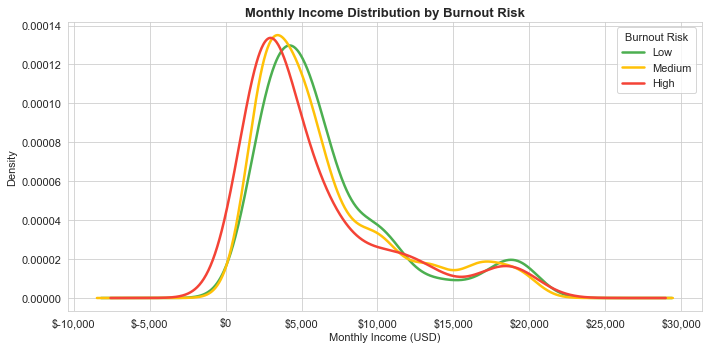

In [ ]:
# MonthlyIncome distribution by BurnoutRisk 
fig, ax = plt.subplots(figsize=(10, 5))

for risk in order:
    subset = df[df['BurnoutRisk'] == risk]['MonthlyIncome']
    subset.plot(kind='kde', ax=ax, label=risk, color=palette[risk], linewidth=2.5)

ax.set_title('Monthly Income Distribution by Burnout Risk', fontsize=13, fontweight='bold')
ax.set_xlabel('Monthly Income (USD)')
ax.set_ylabel('Density')
ax.legend(title='Burnout Risk')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

**Interpretation:**
Employees with **High burnout risk** tend to be concentrated in the **lower income range**.
The `Low` burnout risk group has a slightly wider spread across income levels.
This confirms that financial stress (lower income) contributes to burnout risk.

### 5.7 Attrition vs BurnoutRisk

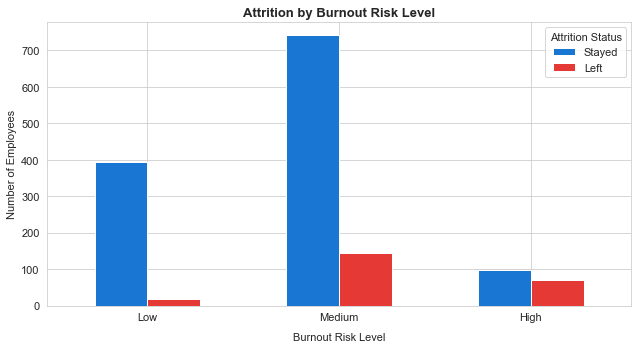

In [ ]:
# Attrition vs BurnoutRisk 
# Attrition: 0 = stayed, 1 = left (after label encoding)
fig, ax = plt.subplots(figsize=(9, 5))

ct = pd.crosstab(df['BurnoutRisk'], df['Attrition'])
ct.columns = ['Stayed', 'Left']
ct = ct.reindex(order)

ct.plot(kind='bar', ax=ax, color=['#1976D2', '#E53935'],
        edgecolor='white', width=0.55)

ax.set_title('Attrition by Burnout Risk Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Burnout Risk Level', labelpad=10)
ax.set_ylabel('Number of Employees')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Attrition Status')

plt.tight_layout()
plt.show()

**Interpretation:**
Employees in the **High burnout risk** group have a noticeably higher proportion of attrition (employees leaving).
This validates our burnout scoring approach — high burnout risk is associated with employees actually leaving the company.

This is a strong validation signal: our engineered `BurnoutRisk` variable aligns with the dataset's
original `Attrition` target, confirming it captures real workplace stress patterns.

---
##  Section 6: Feature Selection

Not all 32 columns are useful for predicting burnout. We select a focused set of features
that are **directly related to burnout** based on HR domain knowledge.

We also exclude:
- `EmployeeNumber` — it's just an ID with no predictive value
- `BurnoutRisk` — that's our target, not a feature
- We avoid using `Attrition` as a feature since it's an outcome that overlaps with burnout

In [ ]:
# Define features (X) and target (y) 
selected_features = [
    # Core burnout-related features
    'OverTime',
    'WorkLifeBalance',
    'JobSatisfaction',
    'EnvironmentSatisfaction',
    'MonthlyIncome',
    'YearsAtCompany',

    # Additional HR features that contribute to stress
    'Age',
    'JobLevel',
    'JobInvolvement',
    'RelationshipSatisfaction',
    'PerformanceRating',
    'TotalWorkingYears',
    'YearsSinceLastPromotion',
    'NumCompaniesWorked',
    'DistanceFromHome',
    'BusinessTravel',
    'MaritalStatus',
    'Department',
    'Gender'
]

X = df[selected_features]
y = df['BurnoutRisk']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape:  {y.shape}")
print(f"\nSelected {len(selected_features)} features")

Feature matrix shape: (1470, 19)
Target vector shape:  (1470,)

Selected 19 features


### Label Encode the Target Variable

Our target `BurnoutRisk` contains text values (`Low`, `Medium`, `High`).
We need to convert it to numbers before training the models.

In [ ]:
#  Encode the target variable 
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print("Target encoding:")
for label, code in zip(le_target.classes_, range(len(le_target.classes_))):
    print(f"  {label} → {code}")

# We'll keep the class names for display purposes
class_names = le_target.classes_
print(f"\nClass names for display: {class_names.tolist()}")

Target encoding:
  High → 0
  Low → 1
  Medium → 2

Class names for display: ['High', 'Low', 'Medium']


---
## Section 7: Train-Test Split

We split the dataset into two parts:
- **Training set (80%)** — used to teach the model
- **Test set (20%)** — used to evaluate how well the model generalises to new data

We use stratify=y_encoded to ensure all three burnout risk classes are proportionally
represented in both the training and test sets.

In [ ]:
# ── Perform an 80-20 stratified train-test split ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded,test_size=0.20,random_state=RANDOM_STATE,stratify=y_encoded)

print(f"Training set:  {X_train.shape[0]} rows  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:      {X_test.shape[0]} rows  ({X_test.shape[0]/len(X)*100:.0f}%)")

# Verify class proportions are preserved
print("\nClass distribution in training set:")
for code, name in enumerate(class_names):
    count = (y_train == code).sum()
    print(f"  {name}: {count} ({count/len(y_train)*100:.1f}%)")

print("\nClass distribution in test set:")
for code, name in enumerate(class_names):
    count = (y_test == code).sum()
    print(f"  {name}: {count} ({count/len(y_test)*100:.1f}%)")

Training set:  1176 rows  (80%)
Test set:      294 rows  (20%)

Class distribution in training set:
  High: 136 (11.6%)
  Low: 331 (28.1%)
  Medium: 709 (60.3%)

Class distribution in test set:
  High: 34 (11.6%)
  Low: 83 (28.2%)
  Medium: 177 (60.2%)


---
##  Section 8: Feature Scaling

### Why is scaling important?

Some features in our dataset have very different ranges. For example:
- MonthlyIncome can be anywhere from **1,009 to 19,999**
- WorkLifeBalance is only **1 to 4**

This large difference in scale can confuse certain models (especially **Logistic Regression**),
making features with larger numbers seem more important than they really are.

**StandardScaler** transforms each feature so it has:
- Mean = 0
- Standard deviation = 1

**Important:** We fit the scaler on the **training data only** and then apply the same
transformation to the test data. This prevents **data leakage** (accidentally using test
information during training).

 **Note:** Tree-based models like Random Forest are not affected by feature scale,
 but we scale anyway to keep the workflow consistent and fair.

In [ ]:
# Scale features using StandardScaler 
scaler = StandardScaler()

# Fit on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Only transform (DO NOT fit) on test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling complete!")
print(f"\nTraining set — scaled shape: {X_train_scaled.shape}")
print(f"Test set     — scaled shape: {X_test_scaled.shape}")

# Quick sanity check: mean and std of scaled training data
print(f"\nTraining data — mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"Training data — std  (should be ~1): {X_train_scaled.std():.4f}")

Feature scaling complete!

Training set — scaled shape: (1176, 19)
Test set     — scaled shape: (294, 19)

Training data — mean (should be ~0): -0.0000
Training data — std  (should be ~1): 1.0000


---
##  Section 9: Stage 1 — Burnout Classification Models

We've now reached the **first critical stage of our system**: classifying employees into burnout risk levels.

After all our data preparation and feature engineering, we have:
- **Cleaned data** with no missing values or duplicates
- **Engineered target**: `BurnoutRisk` (Low, Medium, High) based on workplace stress indicators
- **Scaled features** ready for model training
- **Train-test split** ensuring fair evaluation

Now we train two classification models that will learn to **predict which category (Low, Medium, High) 
each employee belongs to** based on their workplace characteristics. These predictions will inform 
Stage 2 (sick-day forecasting) and Stage 3 (HR interventions).

---

### 9.1 Model 1: Logistic Regression — Finding the Decision Boundaries

**What is Logistic Regression doing in our project?**

Logistic Regression will learn to find **linear decision boundaries** that separate employees into 
our three burnout risk categories. Imagine drawing lines on a plot that say "this region is Low risk, 
this region is Medium risk, this region is High risk."

**How it works:**
- Takes all 30 features (age, income, satisfaction, overtime, etc.)
- Learns how much each feature contributes to burnout risk
- Creates a mathematical formula to score each employee
- Classifies them based on that score

**Why we use it:**
- **Fast and interpretable**: We can see which features matter most
- **Serves as a baseline**: A simple model we can compare complex models against
- **Good on tabular data**: Perfect for our structured HR employee data

Even if it doesn't achieve the highest accuracy, it provides a reference point. If a fancy ensemble model 
only barely beats Logistic Regression, the added complexity might not be worth it.

In [ ]:
#  Train Logistic Regression 
lr_model = LogisticRegression(max_iter=1000,random_state=RANDOM_STATE)
lr_model.fit(X_train_scaled, y_train)

# Generate predictions on the test set
lr_preds = lr_model.predict(X_test_scaled)



### 9.2 Model 2: Random Forest Classifier — Capturing Complex Patterns

**What is Random Forest doing in our project?**

While Logistic Regression assumes employees can be separated by simple linear patterns, Random Forest 
takes a different approach: it **builds 100 decision trees**, each learning different patterns in the data, 
then combines their predictions.

**How it works:**
- Builds 100 independent decision trees, each on random subsets of employees and features
- Each tree learns questions like: "Is WorkLifeBalance < 2? If yes, go left..."
- For a new employee, all 100 trees vote on their burnout risk category
- The majority vote becomes the prediction

**Why we use it after Logistic Regression:**
- **Captures non-linear relationships**: Maybe high burnout happens when (Overtime=Yes AND Satisfaction<2), not just one or the other
- **Handles feature interactions**: Understands that the combination of income AND age matters differently than each alone
- **More powerful**: Generally outperforms simple linear models on complex HR data
- **Feature importance**: Tells us which factors matter most for burnout

The tradeoff: Random Forest is less interpretable ("why did it make this decision?") but typically more accurate. 
This is our workhorse model for Stage 1.

In [ ]:
# Train Random Forest Classifier 
rf_model = RandomForestClassifier(n_estimators=100,max_depth=None,random_state=RANDOM_STATE,n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Generate predictions on the test set
rf_preds = rf_model.predict(X_test_scaled)



---
##  Section 10: Model Evaluation — Comparing Stage 1 Results

Now that both models are trained, we need to **evaluate how well they classify employees into burnout 
risk categories**. A model that randomly guesses would be worthless; we need one that reliably identifies 
who is at High, Medium, or Low risk.

**Why evaluation matters for our project:**
- **Stage 1 success** drives everything downstream
- Wrong classifications in Stage 1 → Wrong sick-day predictions in Stage 2 → Wrong interventions in Stage 3
- We must choose the best model for production use

We evaluate both models using several metrics to get a complete picture of performance:

| Metric | What it measures | Why it matters |
|---|---|---|
| **Accuracy** | % of employees correctly classified | Overall correctness |
| **Precision** | Of all employees we flag as "High risk," how many actually are? | Avoid false alarms |
| **Recall** | Of all true "High risk" employees, how many did we find? | Don't miss at-risk people |
| **F1-Score** | Harmonic mean of Precision and Recall | Best single metric for imbalanced classes |

We use **macro averaging** (treating all three classes equally) because missing even one High-risk employee 
is as important as correctly classifying Low-risk employees.

### 10.1 Logistic Regression — Evaluation

In [ ]:
#  Helper function to print evaluation metrics cleanly 
def evaluate_model(model_name, y_true, y_pred, class_names):
    """Print a clean summary of evaluation metrics for a classification model."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)

    print(f"{'='*55}")
    print(f"  Model: {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}  (macro average)")
    print(f"  Recall    : {rec:.4f}  (macro average)")
    print(f"  F1-Score  : {f1:.4f}  (macro average)")
    print(f"{'='*55}")
    print()
    print("Classification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=class_names,
                                zero_division=0))


#  Evaluate Logistic Regression 
evaluate_model("Logistic Regression", y_test, lr_preds, class_names)

  Model: Logistic Regression
  Accuracy  : 0.8605  (86.05%)
  Precision : 0.8796  (macro average)
  Recall    : 0.8311  (macro average)
  F1-Score  : 0.8525  (macro average)

Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.79      0.87        34
         Low       0.80      0.80      0.80        83
      Medium       0.87      0.90      0.89       177

    accuracy                           0.86       294
   macro avg       0.88      0.83      0.85       294
weighted avg       0.86      0.86      0.86       294



### 10.2 Logistic Regression — Confusion Matrix

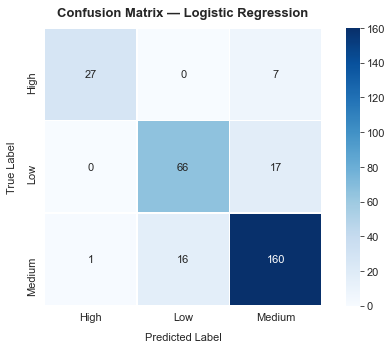

In [ ]:
#  Plot Confusion Matrix for Logistic Regression 
cm_lr = confusion_matrix(y_test, lr_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, square=True)
plt.title('Confusion Matrix — Logistic Regression', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Predicted Label', labelpad=10)
plt.ylabel('True Label', labelpad=10)
plt.tight_layout()
plt.show()

**How to read the confusion matrix:**
- The **diagonal** cells (top-left to bottom-right) represent **correct** predictions.
- **Off-diagonal** cells represent **mistakes** — where the model predicted the wrong class.
- A good model has large numbers on the diagonal and small numbers elsewhere.

### 10.3 Random Forest — Evaluation

In [ ]:
#  Evaluate Random Forest 
evaluate_model("Random Forest Classifier", y_test, rf_preds, class_names)

  Model: Random Forest Classifier
  Accuracy  : 0.9456  (94.56%)
  Precision : 0.9568  (macro average)
  Recall    : 0.8706  (macro average)
  F1-Score  : 0.9033  (macro average)

Classification Report:
              precision    recall  f1-score   support

        High       0.96      0.65      0.77        34
         Low       0.99      0.98      0.98        83
      Medium       0.93      0.99      0.96       177

    accuracy                           0.95       294
   macro avg       0.96      0.87      0.90       294
weighted avg       0.95      0.95      0.94       294



### 10.4 Random Forest — Confusion Matrix

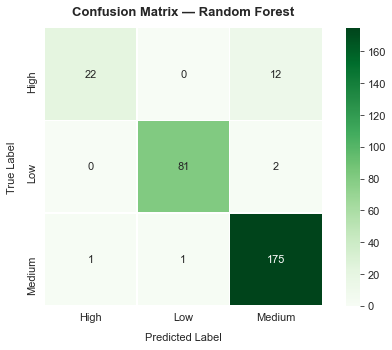

In [ ]:
#  Plot Confusion Matrix for Random Forest 
cm_rf = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, square=True)
plt.title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Predicted Label', labelpad=10)
plt.ylabel('True Label', labelpad=10)
plt.tight_layout()
plt.show()

### 10.5 Model Comparison

Let's put both models side by side to see which one performs better.

In [ ]:
# Side-by-side model comparison 
results = {
    'Logistic Regression': {
        'Accuracy' : accuracy_score(y_test, lr_preds),
        'Precision': precision_score(y_test, lr_preds, average='macro', zero_division=0),
        'Recall'   : recall_score(y_test, lr_preds, average='macro', zero_division=0),
        'F1-Score' : f1_score(y_test, lr_preds, average='macro', zero_division=0)
    },
    'Random Forest': {
        'Accuracy' : accuracy_score(y_test, rf_preds),
        'Precision': precision_score(y_test, rf_preds, average='macro', zero_division=0),
        'Recall'   : recall_score(y_test, rf_preds, average='macro', zero_division=0),
        'F1-Score' : f1_score(y_test, rf_preds, average='macro', zero_division=0)
    }
}

results_df = pd.DataFrame(results).T.round(4)
print("Model Comparison Table (macro-averaged metrics):")
print(results_df.to_string())

best_model = results_df['F1-Score'].idxmax()
print(f"\n Best model by F1-Score: {best_model}  ({results_df.loc[best_model, 'F1-Score']:.4f})")

Model Comparison Table (macro-averaged metrics):
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression    0.8605     0.8796  0.8311    0.8525
Random Forest          0.9456     0.9568  0.8706    0.9033

 Best model by F1-Score: Random Forest  (0.9033)


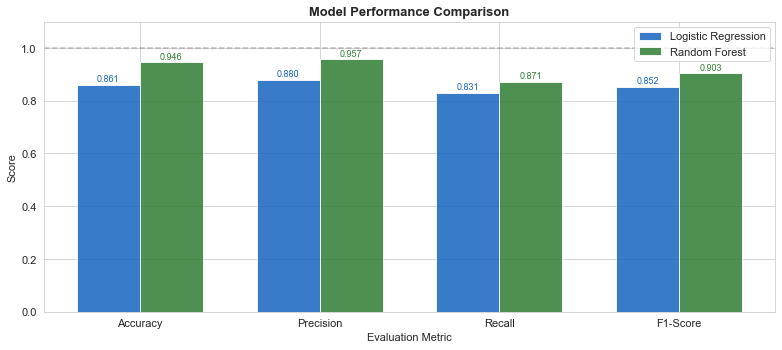

In [ ]:
# Visual comparison of model metrics 
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

bars1 = ax.bar(x - width/2,
               [results['Logistic Regression'][m] for m in metrics],
               width, label='Logistic Regression', color='#1565C0', alpha=0.85)
bars2 = ax.bar(x + width/2,
               [results['Random Forest'][m] for m in metrics],
               width, label='Random Forest', color='#2E7D32', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#1565C0')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#2E7D32')

ax.set_title('Model Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xlabel('Evaluation Metric')
ax.set_ylabel('Score')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.10)
ax.legend()
ax.axhline(y=1.0, color='grey', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 10.6 Feature Importance — Random Forest

One advantage of Random Forest is that it tells us which features were most useful
for making predictions. This is called **feature importance**.

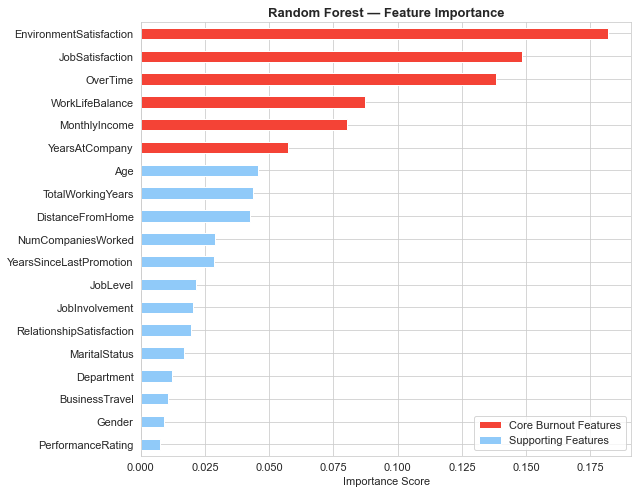

In [ ]:
#  Plot feature importance from Random Forest 
importances = pd.Series(rf_model.feature_importances_, index=selected_features)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#F44336' if f in ['OverTime', 'WorkLifeBalance', 'JobSatisfaction',
                              'EnvironmentSatisfaction', 'MonthlyIncome', 'YearsAtCompany']
          else '#90CAF9'
          for f in importances.index]

importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('')

# Add a legend to distinguish core burnout features
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#F44336', label='Core Burnout Features'),
    Patch(facecolor='#90CAF9', label='Supporting Features')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

**Interpretation:**
The Random Forest model confirms our feature engineering choices. The features we used to
construct `BurnoutRisk` — `MonthlyIncome`, `OverTime`, `JobSatisfaction`, `WorkLifeBalance`,
and `EnvironmentSatisfaction` — rank as the **most important predictors**.

This is a strong validation: the model independently learned that the same features
we used to create the target variable are the most informative.

---
##  Section 11: Save Cleaned Dataset for Stage 2

Now that we have finished Stage 1, we save the cleaned and preprocessed dataset
to a CSV file so it can be used directly as the **input to Stage 2** (Sick-Day Forecasting).

### What this file contains

The saved file includes:
- All original columns (minus the three constant columns that were dropped)
- All categorical columns **already label-encoded** — no re-encoding needed in Stage 2
- The new **`BurnoutRisk`** column (text: `Low` / `Medium` / `High`) for reference
- A new **`BurnoutRisk_Encoded`** column (numeric: `0` / `1` / `2`) ready for modelling

> In Stage 2 you can load this file directly with `pd.read_csv('hr_cleaned_stage2.csv')`
> and start building the sick-day regression model without repeating any cleaning steps.

In [ ]:
# Add the numeric encoded version of BurnoutRisk to the dataframe 
# le_target was fitted earlier: High=0, Low=1, Medium=2
df['BurnoutRisk_Encoded'] = le_target.transform(df['BurnoutRisk'])

# Save to CSV 
output_filename = 'Data/hr_cleaned_stage2.csv'
df.to_csv(output_filename, index=False)

# Confirm what was saved 
print(f" Cleaned dataset saved as: '{output_filename}'")
print(f"   Rows    : {df.shape[0]}")
print(f"   Columns : {df.shape[1]}")
print()

print("Encoding mapping (BurnoutRisk → BurnoutRisk_Encoded):")
print(df[['BurnoutRisk', 'BurnoutRisk_Encoded']].drop_duplicates()
        .sort_values('BurnoutRisk_Encoded').to_string(index=False))
print()
print("First 3 rows of saved file:")
df.head(3)

 Cleaned dataset saved as: 'Data/hr_cleaned_stage2.csv'
   Rows    : 1470
   Columns : 34

Encoding mapping (BurnoutRisk → BurnoutRisk_Encoded):
BurnoutRisk  BurnoutRisk_Encoded
       High                    0
        Low                    1
     Medium                    2

First 3 rows of saved file:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BurnoutRisk,BurnoutRisk_Encoded
0,41,1,2,1102,2,1,2,1,1,2,...,0,8,0,1,6,4,0,5,High,0
1,49,0,1,279,1,8,1,1,2,3,...,1,10,3,3,10,7,1,7,Low,1
2,37,1,2,1373,1,2,2,4,4,4,...,0,7,3,3,0,0,0,0,Medium,2


---
##  Section 12: Stage 2 — Sick-Day Prediction (Regression)

**Moving from classification to forecasting...**

In Stage 1, we classified employees as Low, Medium, or High burnout risk. Now in Stage 2, we take the 
**next step in our predictive system**: forecasting **how many sick days** each employee will likely take.

**Why predict sick days?**
- **Absenteeism is burnout's symptom**: Burnt-out employees take more sick days (real or just to escape)
- **HR impact**: Helps with staffing plans, resource allocation, and identifying who needs intervention
- **Early warning**: High absenteeism predictions combined with High burnout classification = urgent need for action
- **Different from burnout level**: Someone might have High burnout but take few sick days (suffering silently) or Medium burnout but many sick days (health issues)

**The challenge:**
The original dataset has **no sick-day data**, so we engineer a **synthetic target variable** based on the 
realistic relationship between burnout factors and absenteeism. We then train **three regression models** 
to learn this relationship.

**Regression vs. Classification:**
- Stage 1 was **classification**: Predict which category (Low/Medium/High) — discrete boxes
- Stage 2 is **regression**: Predict a number (0-25 days) — a continuous value

**Three regression models compared:**
1. **Linear Regression** — Simple baseline: assumes burnout factors scale linearly to sick days
2. **Random Forest Regressor** — Ensemble: captures non-linear patterns and interactions
3. **XGBoost Regressor** — Gradient boosting: state-of-the-art sequential learning

In [86]:
#  Load the cleaned Stage 2 dataset 
df_stage2 = pd.read_csv('Data/hr_cleaned_stage2.csv')

print("Stage 2 dataset loaded successfully!")
print(f"Shape: {df_stage2.shape[0]} rows × {df_stage2.shape[1]} columns")
print(f"\nFirst few rows:")
df_stage2.head()

Stage 2 dataset loaded successfully!
Shape: 1470 rows × 34 columns

First few rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BurnoutRisk,BurnoutRisk_Encoded
0,41,1,2,1102,2,1,2,1,1,2,...,0,8,0,1,6,4,0,5,High,0
1,49,0,1,279,1,8,1,1,2,3,...,1,10,3,3,10,7,1,7,Low,1
2,37,1,2,1373,1,2,2,4,4,4,...,0,7,3,3,0,0,0,0,Medium,2
3,33,0,1,1392,1,3,4,1,5,4,...,0,8,3,3,8,7,3,0,Medium,2
4,27,0,2,591,1,2,1,3,7,1,...,1,6,3,3,2,2,2,2,Medium,2


### 12.2 Engineer Synthetic Target Variable (Sick Days)

Since the original dataset does not contain sick-day records, we will create a synthetic
target variable based on burnout and stress indicators. This synthetic variable models
the realistic relationship between burnout factors and employee absenteeism.

**Sick days are estimated using:**
- **Overtime** — Working long hours increases stress and illness
- **Job Satisfaction** — Low satisfaction leads to more sick days
- **Work-Life Balance** — Poor balance increases absenteeism
- **Environment Satisfaction** — Unhappy environment correlates with more absences
- **Monthly Income** — Lower income correlates with higher absenteeism (proxy for job stress)

**Formula:** Base sick days + contributions from each stress factor


In [87]:
# Engineer synthetic sick days target variable 
# Base sick days (average employee)
base_sick_days = 8

# Create synthetic sick days using burnout and stress factors
# Higher stress = more sick days
df_stage2['SickDays'] = (
    base_sick_days +                                      # baseline
    (df_stage2['OverTime'] == 'Yes').astype(int) * 4 +    # overtime adds days
    (5 - df_stage2['JobSatisfaction']) * 1.5 +            # low satisfaction adds days
    (5 - df_stage2['WorkLifeBalance']) * 2 +              # poor WLB adds most
    (5 - df_stage2['EnvironmentSatisfaction']) * 1.2 +    # unhappy environment
    (df_stage2['MonthlyIncome'] < df_stage2['MonthlyIncome'].median()).astype(int) * 3  # low income
)

# Round to nearest integer and ensure reasonable bounds (0-25 days/year)
df_stage2['SickDays'] = np.clip(df_stage2['SickDays'].round(), 0, 25)

print("Synthetic sick days variable engineered!")
print(f"\nSick Days Statistics:")
print(df_stage2['SickDays'].describe())
print(f"\nSample of data with engineered sick days:")
print(df_stage2[['SickDays', 'OverTime', 'JobSatisfaction', 'WorkLifeBalance', 'BurnoutRisk']].head(10))


Synthetic sick days variable engineered!

Sick Days Statistics:
count    1470.000000
mean       20.046259
std         2.822507
min        13.000000
25%        18.000000
50%        20.000000
75%        22.000000
max        25.000000
Name: SickDays, dtype: float64

Sample of data with engineered sick days:
   SickDays  OverTime  JobSatisfaction  WorkLifeBalance BurnoutRisk
0      21.0         1                4                1        High
1      19.0         0                2                3         Low
2      19.0         1                3                3      Medium
3      19.0         1                3                3      Medium
4      24.0         0                2                3      Medium
5      20.0         0                4                2         Low
6      25.0         1                1                2        High
7      19.0         0                3                3         Low
8      16.0         0                3                3         Low
9      19.0   

### 12.3 Prepare Features and Train-Test Split for Regression

We prepare the feature matrix and target variable for regression.
We use the **same features** as Stage 1 (burnout indicators), which have already
been label-encoded and scaled.


In [ ]:
# Prepare regression features and target 
# Use the same features as Stage 1 (already encoded)
regression_features = [col for col in df_stage2.columns 
                       if col not in ['EmployeeNumber', 'BurnoutRisk', 'BurnoutRisk_Encoded', 'SickDays']]

X_reg = df_stage2[regression_features]
y_reg = df_stage2['SickDays']

print(f"Feature matrix shape: {X_reg.shape}")
print(f"Target shape: {y_reg.shape}")

#  Train-Test Split for Regression 
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

print(f"\nTrain set: {X_train_reg.shape[0]} samples")
print(f"Test set:  {X_test_reg.shape[0]} samples")

# Scale features for regression 
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)


Feature matrix shape: (1470, 31)
Target shape: (1470,)

Train set: 1176 samples
Test set:  294 samples

Feature scaling complete for regression models!


---
##  Section 13: Stage 2 — Regression Models

### 13.1 Model 1: Linear Regression

Linear Regression is the simplest regression model. It assumes a linear relationship
between features and the target (sick days). While simple, it serves as a good baseline
for comparing against more complex models.




In [88]:
# Train Linear Regression 
lr_reg_model = LinearRegression()
lr_reg_model.fit(X_train_reg_scaled, y_train_reg)

# Generate predictions on the test set
y_pred_lr_reg = lr_reg_model.predict(X_test_reg_scaled)


### 13.2 Model 2: Random Forest Regressor

Random Forest Regressor builds multiple decision trees and averages their predictions.
It captures non-linear relationships and interactions between features better than
Linear Regression.




In [89]:
#  Train Random Forest Regressor 
rf_reg_model = RandomForestRegressor(n_estimators=100,max_depth=15,random_state=RANDOM_STATE,n_jobs=-1)
rf_reg_model.fit(X_train_reg_scaled, y_train_reg)

# Generate predictions on the test set
y_pred_rf_reg = rf_reg_model.predict(X_test_reg_scaled)


### 13.3 Model 3: XGBoost Regressor

XGBoost (Extreme Gradient Boosting) is a state-of-the-art gradient boosting algorithm.
It builds trees sequentially, with each tree correcting the errors of previous trees.
XGBoost is known for high accuracy and often wins machine learning competitions.



In [90]:
# Train XGBoost Regressor 
xgb_reg_model = XGBRegressor(n_estimators=100,max_depth=6,learning_rate=0.1,random_state=RANDOM_STATE,verbosity=0)

xgb_reg_model.fit(X_train_reg_scaled, y_train_reg)

# Generate predictions on the test set
y_pred_xgb_reg = xgb_reg_model.predict(X_test_reg_scaled)


---
##  Section 14: Regression Model Evaluation

For regression tasks, we use different metrics than classification:

**MAE (Mean Absolute Error)** -> Average absolute difference between predicted and actual values (in days) 

**RMSE (Root Mean Squared Error)** -> Square root of average squared errors (penalizes large errors more)

**R² Score** -> Proportion of variance explained (1.0 = perfect, 0.0 = no better than mean) 

**Interpretation:**
- **Lower MAE/RMSE = Better** (fewer days of prediction error)
- **Higher R² = Better** (model explains more variance)

### 14.1 Define Regression Evaluation Function


In [ ]:
# Helper function to evaluate regression models 
def evaluate_regression_model(model_name, y_true, y_pred):
    """Print a clean summary of evaluation metrics for a regression model."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

  
    print(f"  Model: {model_name}")
    print(f"  MAE  (Mean Absolute Error)  : {mae:.4f} days")
    print(f"  RMSE (Root Mean Squared Error): {rmse:.4f} days")
    print(f"  R² Score                     : {r2:.4f}")
    print()

# Evaluate all three regression models

evaluate_regression_model("Linear Regression", y_test_reg, y_pred_lr_reg)
evaluate_regression_model("Random Forest Regressor", y_test_reg, y_pred_rf_reg)
evaluate_regression_model("XGBoost Regressor", y_test_reg, y_pred_xgb_reg)


  Model: Linear Regression
  MAE  (Mean Absolute Error)  : 0.9624 days
  RMSE (Root Mean Squared Error): 1.1310 days
  R² Score                     : 0.8429

  Model: Random Forest Regressor
  MAE  (Mean Absolute Error)  : 0.1226 days
  RMSE (Root Mean Squared Error): 0.2633 days
  R² Score                     : 0.9915

  Model: XGBoost Regressor
  MAE  (Mean Absolute Error)  : 0.0751 days
  RMSE (Root Mean Squared Error): 0.1670 days
  R² Score                     : 0.9966



### 14.2 Model Comparison — Side by Side

Let's compare all three regression models visually to see which one performs best.


In [ ]:
#  Create a comparison table for regression models 
regression_results = {
    'Linear Regression': {
        'MAE': mean_absolute_error(y_test_reg, y_pred_lr_reg),
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_lr_reg)),
        'R² Score': r2_score(y_test_reg, y_pred_lr_reg)
    },
    'Random Forest': {
        'MAE': mean_absolute_error(y_test_reg, y_pred_rf_reg),
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_rf_reg)),
        'R² Score': r2_score(y_test_reg, y_pred_rf_reg)
    },
    'XGBoost': {
        'MAE': mean_absolute_error(y_test_reg, y_pred_xgb_reg),
        'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb_reg)),
        'R² Score': r2_score(y_test_reg, y_pred_xgb_reg)
    }
}

reg_results_df = pd.DataFrame(regression_results).T.round(4)
print("Regression Model Comparison Table:")
print(reg_results_df.to_string())

best_model_reg = reg_results_df['R² Score'].idxmax()
print(f"\n Best model by R² Score: {best_model_reg}  ({reg_results_df.loc[best_model_reg, 'R² Score']:.4f})")


Regression Model Comparison Table:
                      MAE    RMSE  R² Score
Linear Regression  0.9624  1.1310    0.8429
Random Forest      0.1226  0.2633    0.9915
XGBoost            0.0751  0.1670    0.9966

 Best model by R² Score: XGBoost  (0.9966)


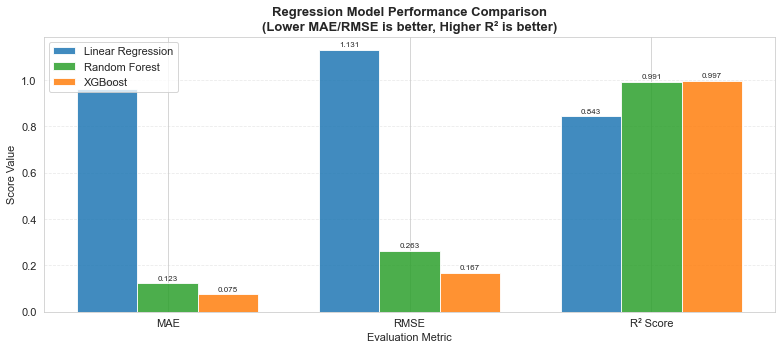

In [99]:
# Visual comparison of regression models
metrics_reg = ['MAE', 'RMSE', 'R² Score']
x_pos = np.arange(len(metrics_reg))
width = 0.25

# Use matplotlib colormap instead of hex colors
colors = plt.cm.tab10.colors   

fig, ax = plt.subplots(figsize=(11, 5))

# Plot bars with new color format
bars1 = ax.bar(x_pos - width,[regression_results['Linear Regression'][m] for m in metrics_reg],width,label='Linear Regression',color=colors[0],alpha=0.85)

bars2 = ax.bar(x_pos,[regression_results['Random Forest'][m] for m in metrics_reg],width,label='Random Forest',color=colors[2],alpha=0.85)

bars3 = ax.bar(x_pos + width,[regression_results['XGBoost'][m] for m in metrics_reg],width,label='XGBoost',color=colors[1],alpha=0.85)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.3f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

# Formatting
ax.set_title('Regression Model Performance Comparison\n'
             '(Lower MAE/RMSE is better, Higher R² is better)',
    fontsize=13,
    fontweight='bold'
)

ax.set_xlabel('Evaluation Metric')
ax.set_ylabel('Score Value')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_reg)
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### 14.3 Actual vs. Predicted — All Models

Let's visualize how well each model predicts sick days compared to actual values.


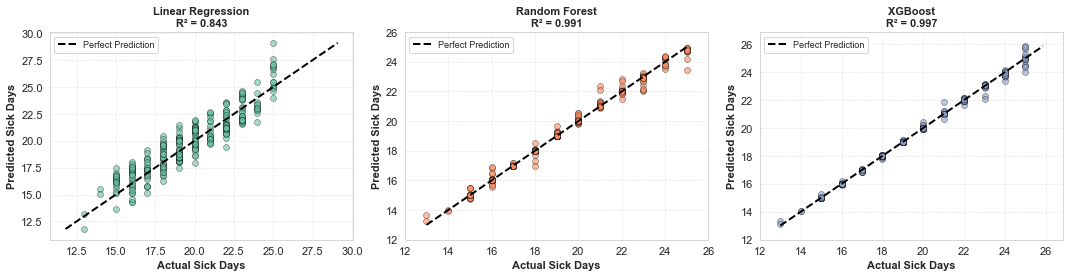

In [96]:
# Create 3-panel plot showing predictions from each model
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Use a built-in matplotlib colormap
colors = plt.cm.Set2.colors

models_info = [
    ('Linear Regression', y_pred_lr_reg, colors[0]),
    ('Random Forest', y_pred_rf_reg, colors[1]),
    ('XGBoost', y_pred_xgb_reg, colors[2])
]

for idx, (name, predictions, color) in enumerate(models_info):
    ax = axes[idx]

    # Scatter plot of actual vs predicted
    ax.scatter(y_test_reg,predictions,alpha=0.6,color=color,edgecolors='black',linewidth=0.5)

    # Perfect prediction line (diagonal)
    min_val = min(y_test_reg.min(), predictions.min())
    max_val = max(y_test_reg.max(), predictions.max())

    ax.plot([min_val, max_val],[min_val, max_val],'k--',lw=2,label='Perfect Prediction')

    ax.set_xlabel('Actual Sick Days', fontweight='bold')
    ax.set_ylabel('Predicted Sick Days', fontweight='bold')

    ax.set_title(f'{name}\nR² = {r2_score(y_test_reg, predictions):.3f}',fontweight='bold',fontsize=11)

    ax.set_xlim(min_val - 1, max_val + 1)
    ax.set_ylim(min_val - 1, max_val + 1)

    ax.grid(linestyle='--', alpha=0.4)
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

### 14.4 Residual Analysis (Prediction Errors)

Residuals (errors) show the difference between actual and predicted values.
Smaller residuals indicate better predictions. We want residuals to be randomly distributed
around zero with no patterns.


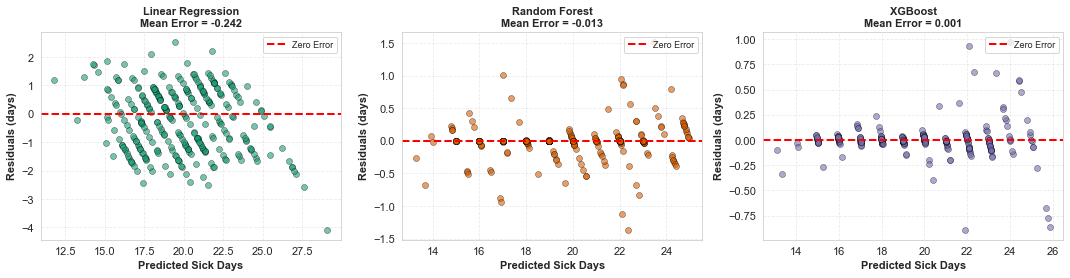

In [97]:
# Calculate residuals
residuals_lr = y_test_reg - y_pred_lr_reg
residuals_rf = y_test_reg - y_pred_rf_reg
residuals_xgb = y_test_reg - y_pred_xgb_reg

# Create 3-panel residual plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Use matplotlib built-in colormap
colors = plt.cm.Dark2.colors

models_residuals = [
    ('Linear Regression', residuals_lr, y_pred_lr_reg, colors[0]),
    ('Random Forest', residuals_rf, y_pred_rf_reg, colors[1]),
    ('XGBoost', residuals_xgb, y_pred_xgb_reg, colors[2])
]

for idx, (name, residuals, predictions, color) in enumerate(models_residuals):
    ax = axes[idx]

    # Residual scatter plot
    ax.scatter(predictions,residuals,alpha=0.6,color=color,edgecolors='black',linewidth=0.5)

    # Add zero-error reference line
    ax.axhline(y=0,color='red',linestyle='--',lw=2,label='Zero Error')

    ax.set_xlabel('Predicted Sick Days', fontweight='bold')
    ax.set_ylabel('Residuals (days)', fontweight='bold')

    ax.set_title(f'{name}\nMean Error = {residuals.mean():.3f}',fontweight='bold',fontsize=11)

    ax.grid(linestyle='--', alpha=0.4)
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

### 14.5 Feature Importance — Tree-Based Models

Both Random Forest and XGBoost can tell us which features are most important for
predicting sick days. This helps understand what workplace factors contribute most
to employee absenteeism.


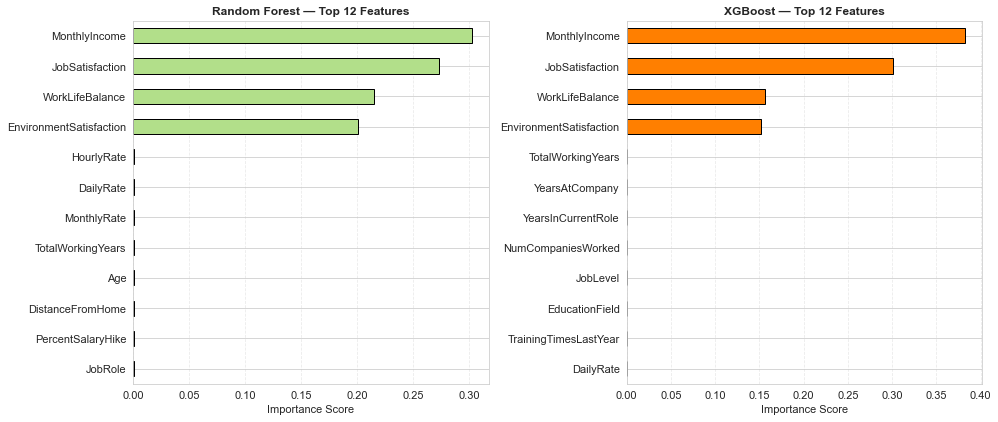


Top 10 Most Important Features by Model:

Random Forest:
[5.12936002e-04 6.12746784e-05 8.58189652e-05 6.07407648e-04
 4.52516521e-05 4.85012085e-04 1.62887036e-04 1.64915290e-04
 2.00949890e-01 4.90744668e-05 8.00898469e-04 1.66479339e-04
 1.33594707e-04 3.93922556e-04 2.73400754e-01 2.41697043e-04
 3.02706439e-01 5.24398595e-04 3.73717002e-04 4.94945563e-05
 4.14414775e-04 4.05905538e-05 1.93046677e-04 1.20934754e-04
 5.12937672e-04 2.84938533e-04 2.15499964e-01 2.82072629e-04
 2.50405077e-04 2.84625685e-04 2.00205632e-04]

XGBoost:
[9.6486467e-05 2.0826339e-04 2.8970544e-04 3.4417535e-04 1.6266375e-04
 1.9919798e-04 2.3858515e-04 4.4726641e-04 1.5206854e-01 1.2391632e-04
 2.6736793e-04 1.9446389e-04 4.7465184e-04 8.6023851e-05 3.0096447e-01
 2.8516111e-04 3.8245663e-01 3.4272965e-04 5.8830791e-04 1.3299266e-04
 2.2484346e-04 0.0000000e+00 1.4088156e-04 1.1137788e-04 8.6842244e-04
 4.2562332e-04 1.5648115e-01 7.0972560e-04 6.9526135e-04 1.9961898e-04
 1.7153044e-04]


In [98]:
# Extract and plot feature importance from tree models

# Feature importance from Random Forest
rf_importances = pd.Series(rf_reg_model.feature_importances_,index=regression_features).sort_values(ascending=True).tail(12)

# Feature importance from XGBoost
xgb_importances = pd.Series(xgb_reg_model.feature_importances_,index=regression_features).sort_values(ascending=True).tail(12)

# Use matplotlib built-in colormap
colors = plt.cm.Paired.colors

# Create side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Random Forest
rf_importances.plot(kind='barh',ax=axes[0],color=colors[2],edgecolor='black')

axes[0].set_title('Random Forest — Top 12 Features',fontsize=12,fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('')
axes[0].grid(axis='x', linestyle='--', alpha=0.4)

# XGBoost
xgb_importances.plot(kind='barh',ax=axes[1],color=colors[7],edgecolor='black')

axes[1].set_title('XGBoost — Top 12 Features',fontsize=12,fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('')
axes[1].grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features by Model:")

print("\nRandom Forest:")
print(rf_reg_model.feature_importances_)

print("\nXGBoost:")
print(xgb_reg_model.feature_importances_)